# Variability-Mode Synthetic Metrics: v4P versus CMIP

Variability-mode synthetic metrics for the four standalone v4P comparison runs.


In [10]:
from pathlib import Path
import importlib
import sys

PROJECT_ROOT = next(
    (path for path in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
     if (path / "scripts").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not find the repository scripts directory.")

SCRIPTS_DIR = PROJECT_ROOT / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

# Reload leaf dependencies before their consumers so notebook reruns use local edits.
import utils
import metrics_group_merger
import movs_metrics_reader
import synthetic_metrics_plotter
import synthetic_metrics_workflow
importlib.reload(utils)
importlib.reload(metrics_group_merger)
importlib.reload(movs_metrics_reader)
importlib.reload(synthetic_metrics_plotter)
importlib.reload(synthetic_metrics_workflow)

from metrics_group_merger import MetricsGroup, PCMDIRun, merge_metrics_group
from synthetic_metrics_workflow import (
    dataset_for_merged_group,
    make_comparison_parameters,
    run_synthetic_plots,
)


In [11]:
# Plot setup: optionally merge one test group, then compare it against CMIP.
MOV_MVO_V4P_CASE_ID = "v20260212"
MOV_MVO_V4P_RUN_PLOTS = True
MOV_MVO_V4P_TITLE_LABEL = "E3SM versus CMIP"

# Set MOV_MVO_V4P_RUN_MERGE=True when raw run JSONs should be merged before plotting.
MOV_MVO_V4P_RUN_MERGE = False
MOV_MVO_V4P_CLEAN_MERGED_OUTPUT = False
MOV_MVO_V4P_DRY_RUN_MERGE = False
MOV_MVO_V4P_DEBUG = True

# Merged metrics location and local config.
MOV_MVO_V4P_METRICS_DATA_ROOT = Path("/global/cfs/cdirs/e3sm/diagnostics/pcmdi_data/metrics_data")
MOV_MVO_V4P_METRIC_CONFIG_FILE = PROJECT_ROOT / "config" / "synthetic_metrics_list.json"
MOV_MVO_V4P_OUTPUT_DIR = Path("/global/cfs/cdirs/e3sm/www/zhan391/eamxx-pcmdi/analysis_output")

# Raw PCMDI diagnostic runs to merge. Each entry matches the PCMDI run setup:
# raw metrics are read from www / case / "pcmdi_diags" / run_type / "metrics_data".
# Plot the merged dataset, including when the merge step is skipped.
MOV_MVO_V4P_TEST_COMBINED = True
MOV_MVO_V4P_TEST_MODEL_ONLY = False
MOV_MVO_V4P_TEST_MIP = "e3sm"
MOV_MVO_V4P_TEST_EXP = "historical"
MOV_MVO_V4P_TEST_MERGED_GROUP = "climo"
MOV_MVO_V4P_TEST_GROUP_LABEL = "E3SM"
MOV_MVO_V4P_TEST_RUNS = [
    PCMDIRun(
        case="20231209.v3.LR.piControl-spinup.chrysalis",
        model_name="EAMXX-ne256_coupled-test",
        metrics_case_id="v20260531",
        output_name="v3.LR.CPL",
        www=Path("/global/cfs/cdirs/e3sm/www/zhan391/eamxx-pcmdi"),
    ),
    PCMDIRun(
        case="20250906.wcycl1850.ne120pg2_r025_RRSwISC6to18E3r5.test6.1.chrysalis",
        model_name="v3-HR_test6-1",
        metrics_case_id="v20260601",
        output_name="v3.HR.CPL",
        www=Path("/global/cfs/cdirs/e3sm/www/zhan391/eamxx-pcmdi"),
    ),
    PCMDIRun(
        case="20260204.ne256.WCYCLXX1850.SOI",
        model_name="EAMXX-ne256_coupled-test",
        metrics_case_id="v20260601",
        output_name="v4P.CPL",
        www=Path("/global/cfs/cdirs/e3sm/www/zhan391/eamxx-pcmdi"),
    ),
    PCMDIRun(
        case="ne256pg2_ne256pg2.F20TR-SCREAMv1.July-1.spanc800.2xauto.acc150.n0032.test2.1",
        model_name="EAMXX_test2_1",
        metrics_case_id="v20260531",
        output_name="v4P.AMIP",
        www=Path("/global/cfs/cdirs/e3sm/www/zhan391/eamxx-pcmdi"),
    ),
]
MOV_MVO_V4P_TEST_HIGHLIGHT_MODELS = [run.output_name or run.model_name for run in MOV_MVO_V4P_TEST_RUNS]

MOV_MVO_V4P_TEST_RAW_GROUP = MetricsGroup(
    name=MOV_MVO_V4P_TEST_MERGED_GROUP,
    model_pattern="*",
    runs=MOV_MVO_V4P_TEST_RUNS,
    mips=[MOV_MVO_V4P_TEST_MIP],
    exps=[MOV_MVO_V4P_TEST_EXP],
    case_id=MOV_MVO_V4P_CASE_ID,
    model_rename=None,
    movs_years=(1850, 2014),
    movs_modes="NAM,NAO,PNA,NPO,SAM,PSA1,PSA2,PDO,NPGO,AMO",
    movs_obses=(
        "NOAA-20C,NOAA-20C,NOAA-20C,NOAA-20C,NOAA-20C,NOAA-20C,NOAA-20C,"
        "HadISST,HadISST,HadISST"
    ),
    enso_collections="ENSO_perf,ENSO_tel,ENSO_proc",
    enso_obses="ERA5,ERA5,ERA5",
)


2026-08-28 16:54:57,216 [INFO]: synthetic_metrics_workflow.py(run_synthetic_plots:641) >> Generating synthetic metrics plots for case_id=v20260212
2026-08-28 16:54:57,216 [INFO]: synthetic_metrics_workflow.py(run_synthetic_plots:646) >> Generating figure_set=variability metrics=[] for case_id=v20260212
2026-08-28 16:54:57,217 [INFO]: synthetic_metrics_plotter.py(generate:363) >> Generating synthetic metrics plots ...
2026-08-28 16:54:57,218 [INFO]: synthetic_metrics_plotter.py(generate:389) >> Processing metric: variability_modes
2026-08-28 16:54:57,218 [INFO]: synthetic_metrics_plotter.py(_handle_variability_modes:490) >> Handling modes variability …
2026-08-28 16:54:57,218 [INFO]: movs_metrics_reader.py(_get_ref_files:158) >> From /pscratch/sd/z/zhan391/e3smv4_project/v4_evaluation/pcmdi_package/jupyter, checking for reference files matching /global/cfs/cdirs/e3sm/diagnostics/pcmdi_data/metrics_data/variability_modes/cmip6/historical/v20220825/*/*/var_mode_*.json
2026-08-28 16:54:57,

[INFO] Using PROJ data: /global/u2/z/zhan391/.conda/envs/e3sm_analysis/share/proj
Test group: E3SM
Reference group: CMIP
Models (0): []
Results: /global/cfs/cdirs/e3sm/www/zhan391/eamxx-pcmdi/analysis_output/model_vs_obs
variability: []


2026-08-28 16:54:57,711 [INFO]: movs_metrics_reader.py(_get_ref_files:158) >> From /pscratch/sd/z/zhan391/e3smv4_project/v4_evaluation/pcmdi_package/jupyter, checking for reference files matching /global/cfs/cdirs/e3sm/diagnostics/pcmdi_data/metrics_data/variability_modes/e3sm/climo/v20260212/*/*/var_mode_*.json
2026-08-28 16:54:57,715 [INFO]: movs_metrics_reader.py(_get_ref_files:160) >> Found 7 matching files
2026-08-28 16:54:58,495 [INFO]: synthetic_metrics_plotter.py(variability_modes_plot_driver:925) >> Processing Portrait  Plots for variability_modes rms....
2026-08-28 16:54:58,504 [INFO]: synthetic_metrics_plotter.py(portrait_metric_plot:1194) >> [Portrait] Highlighted model order: ['v3.LR.CPL', 'v3.HR.CPL', 'v4P.CPL', 'v4P.AMIP']


len(mode_season_list) = 18
data_nor shape = (18, 66)
data_nor.T shape = (66, 18)
existing data_dict shape = (66, 18)
existing columns (n) = 18


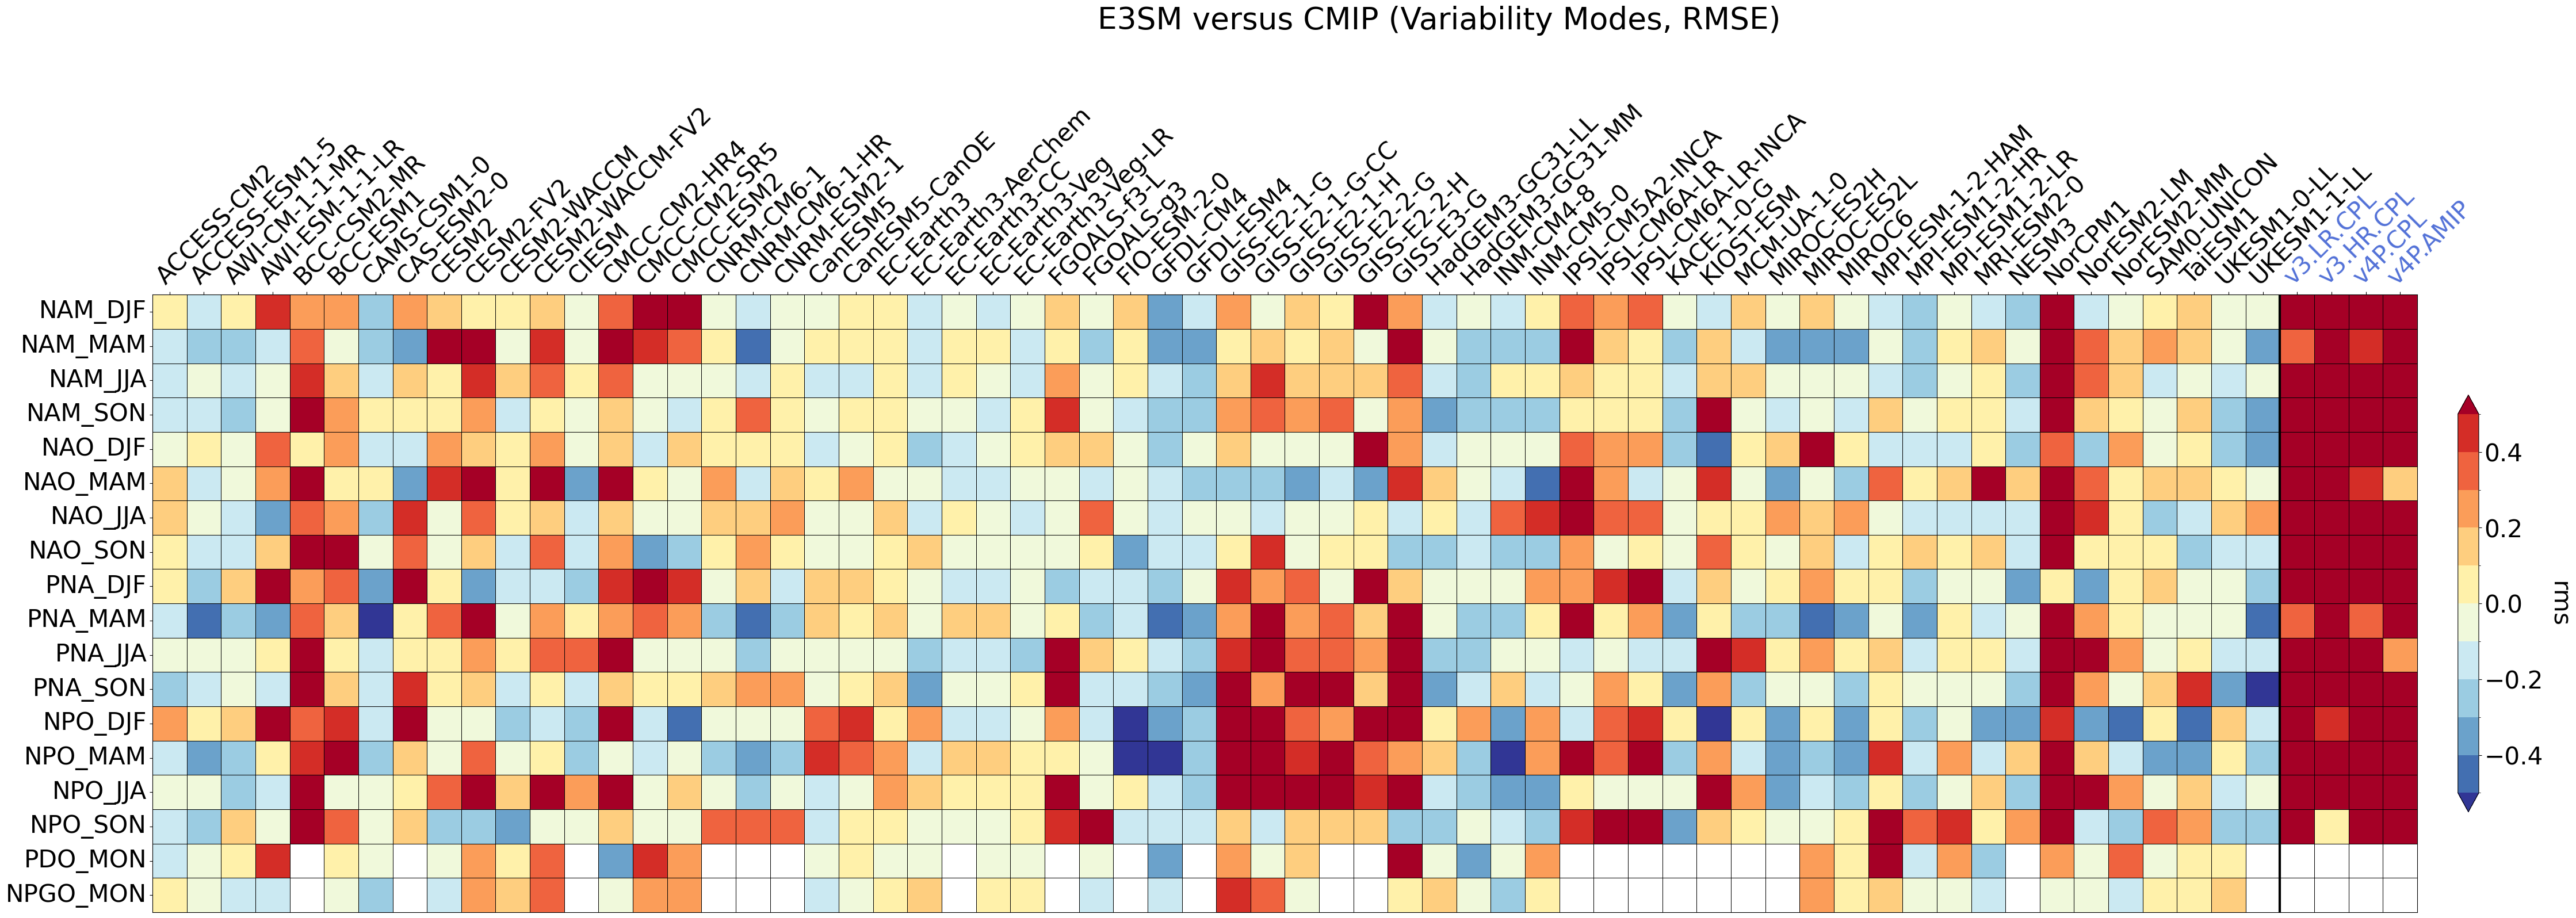

2026-08-28 16:55:00,617 [INFO]: synthetic_metrics_plotter.py(variability_modes_plot_driver:976) >> Processing Parallel Coordinate Plots for variability_modes rms....


Models in the second group: ['v3.HR.CPL', 'v3.LR.CPL', 'v4P.AMIP', 'v4P.CPL']


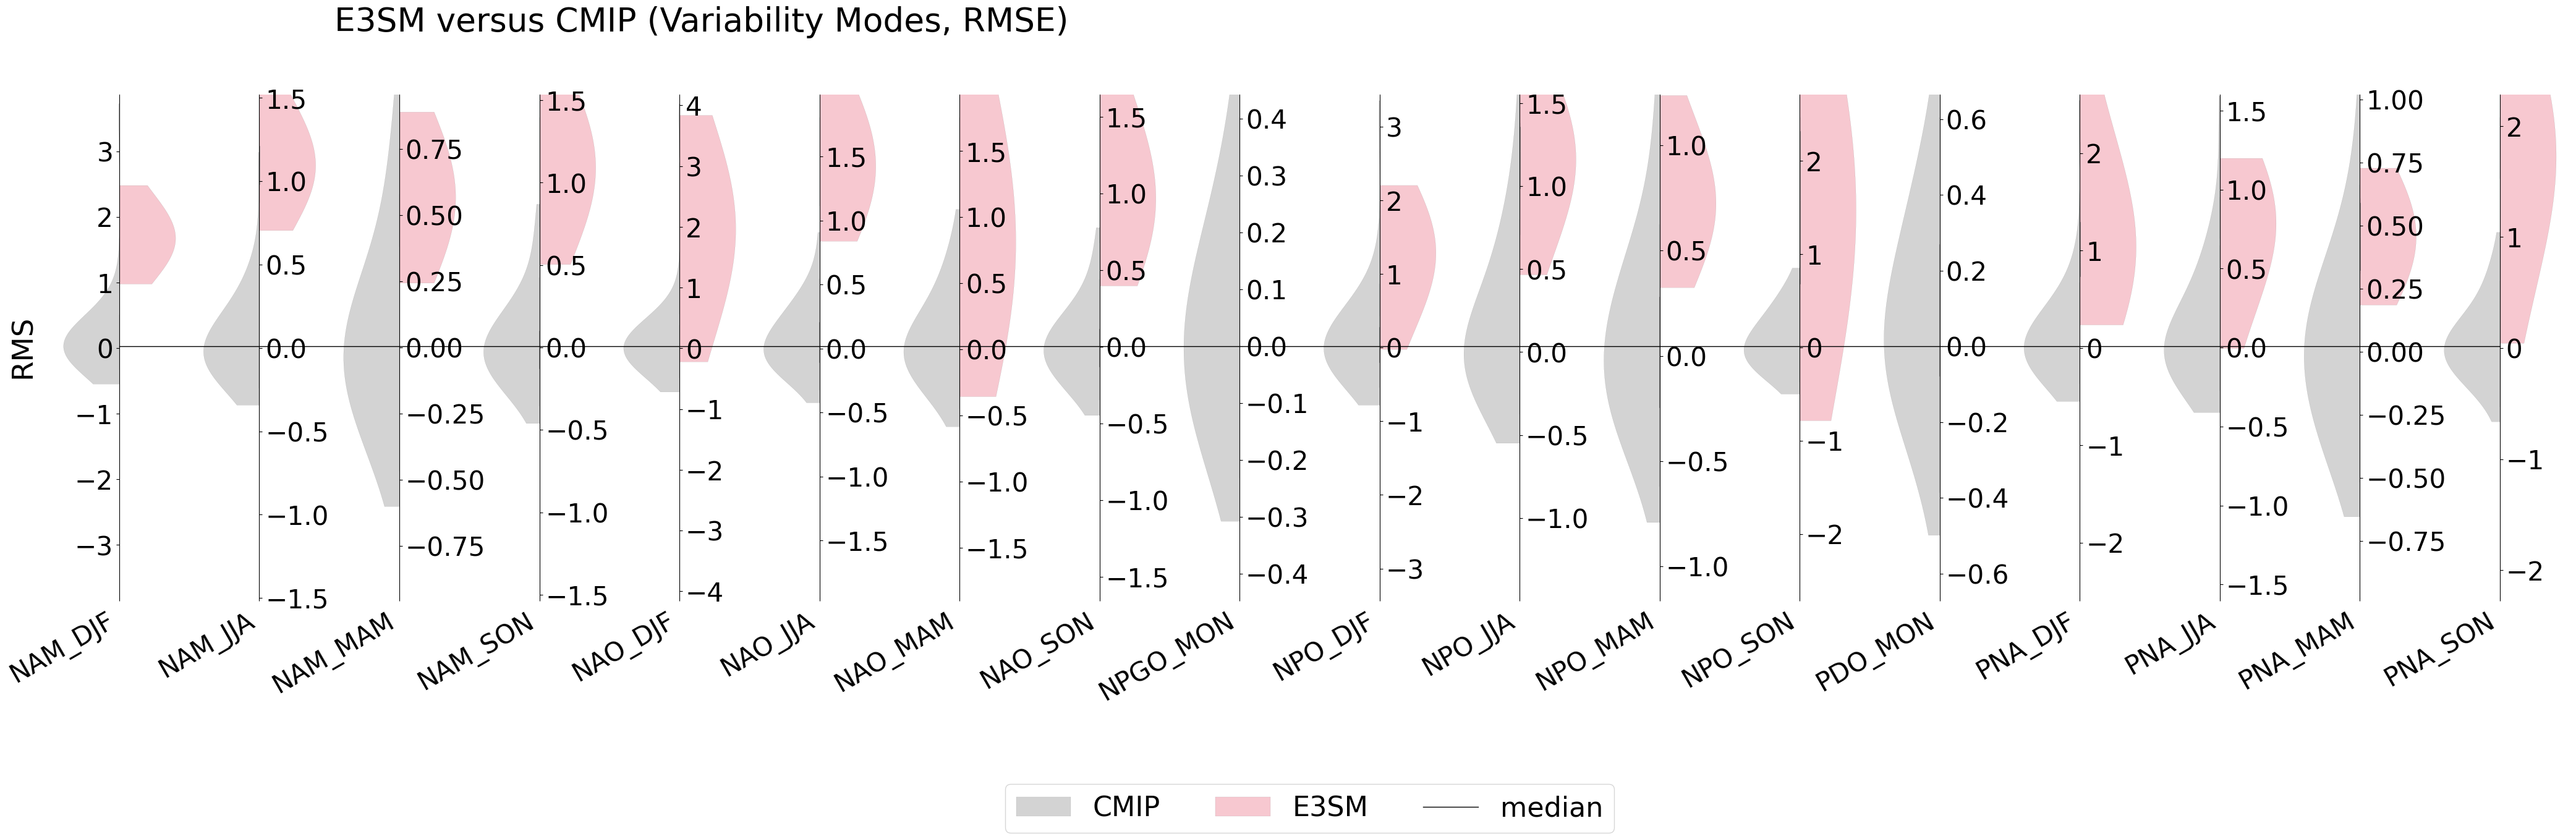

2026-08-28 16:55:03,568 [INFO]: synthetic_metrics_plotter.py(variability_modes_plot_driver:925) >> Processing Portrait  Plots for variability_modes rmsc....
2026-08-28 16:55:03,576 [INFO]: synthetic_metrics_plotter.py(portrait_metric_plot:1194) >> [Portrait] Highlighted model order: ['v3.LR.CPL', 'v3.HR.CPL', 'v4P.CPL', 'v4P.AMIP']


len(mode_season_list) = 18
data_nor shape = (18, 66)
data_nor.T shape = (66, 18)
existing data_dict shape = (66, 18)
existing columns (n) = 18


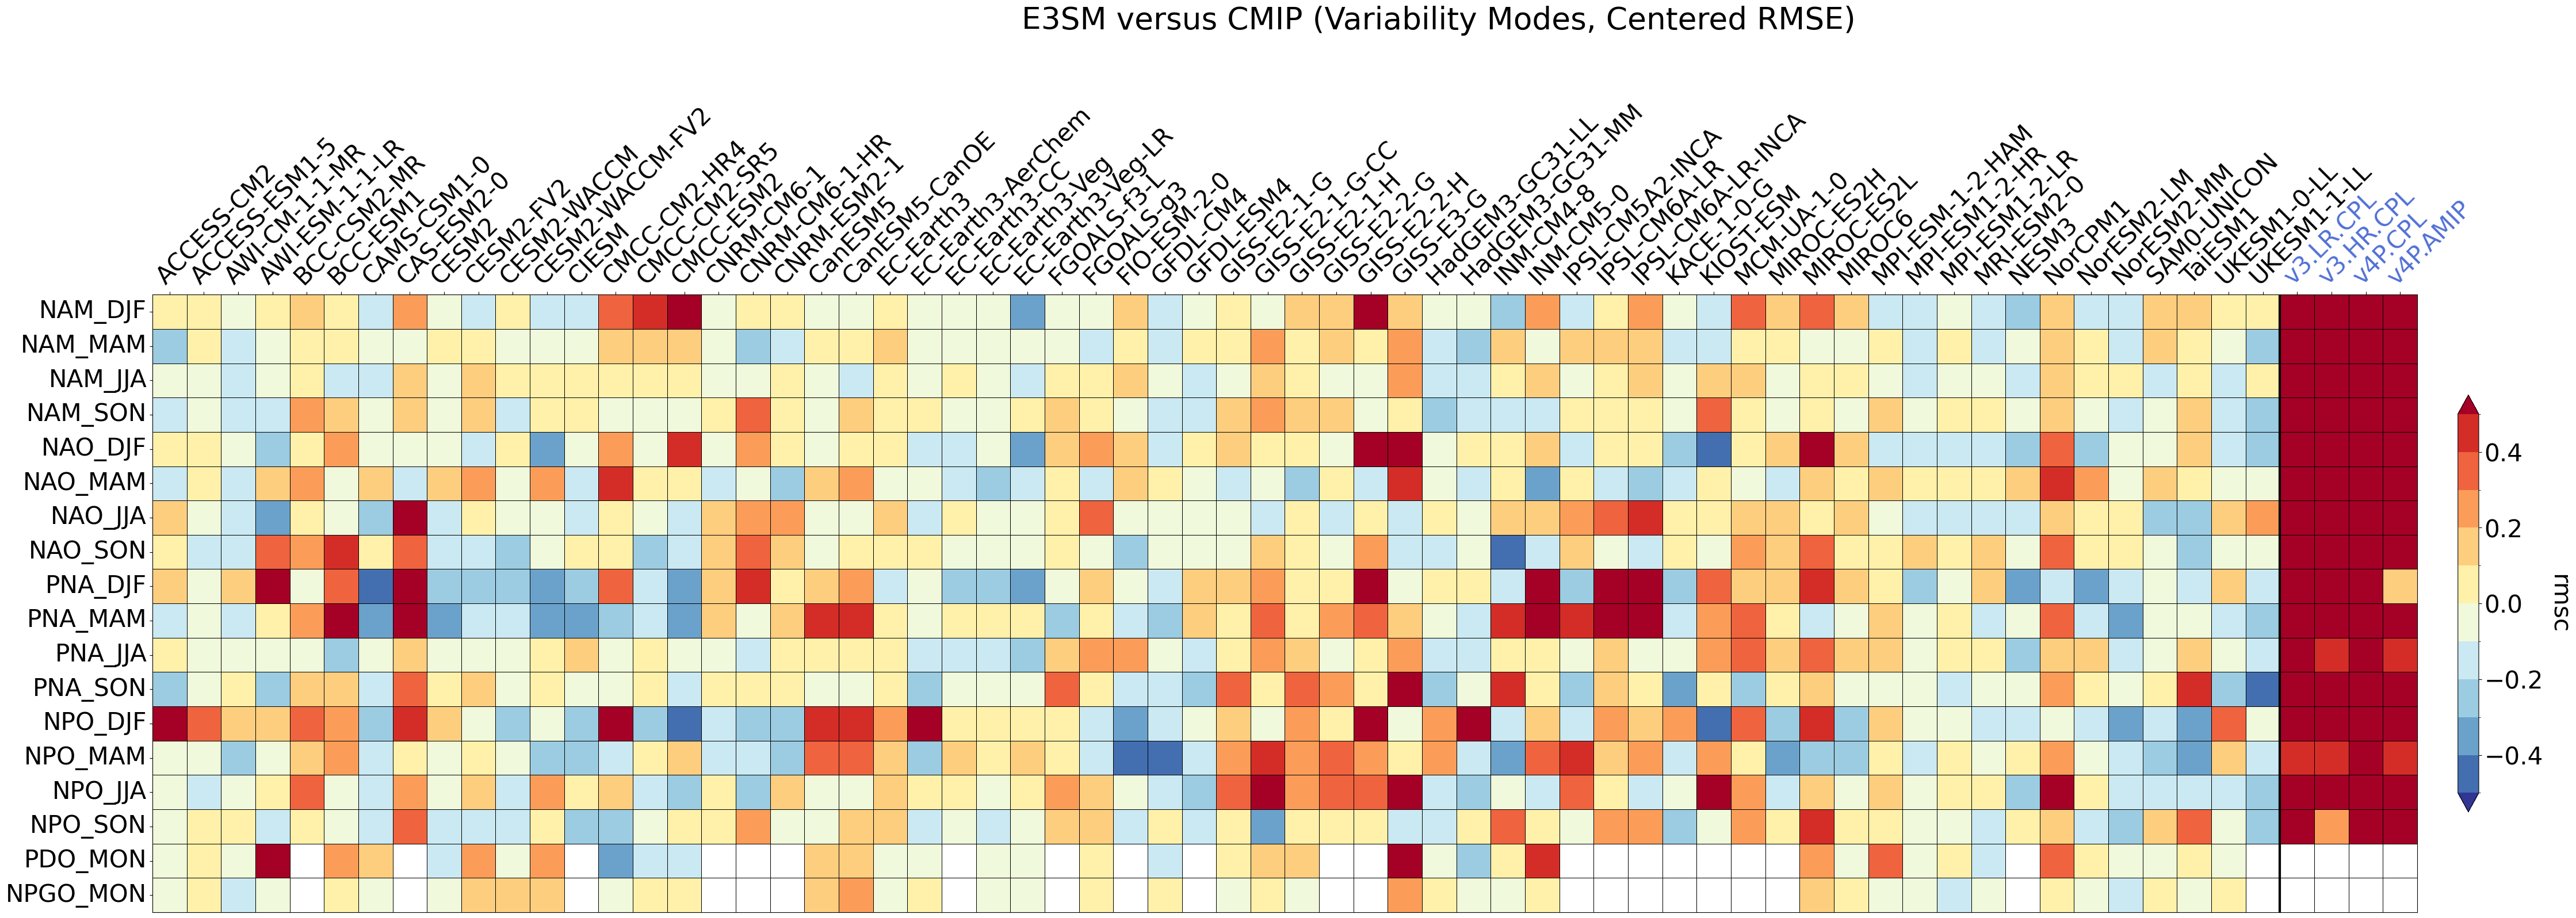

2026-08-28 16:55:05,413 [INFO]: synthetic_metrics_plotter.py(variability_modes_plot_driver:976) >> Processing Parallel Coordinate Plots for variability_modes rmsc....


Models in the second group: ['v3.HR.CPL', 'v3.LR.CPL', 'v4P.AMIP', 'v4P.CPL']


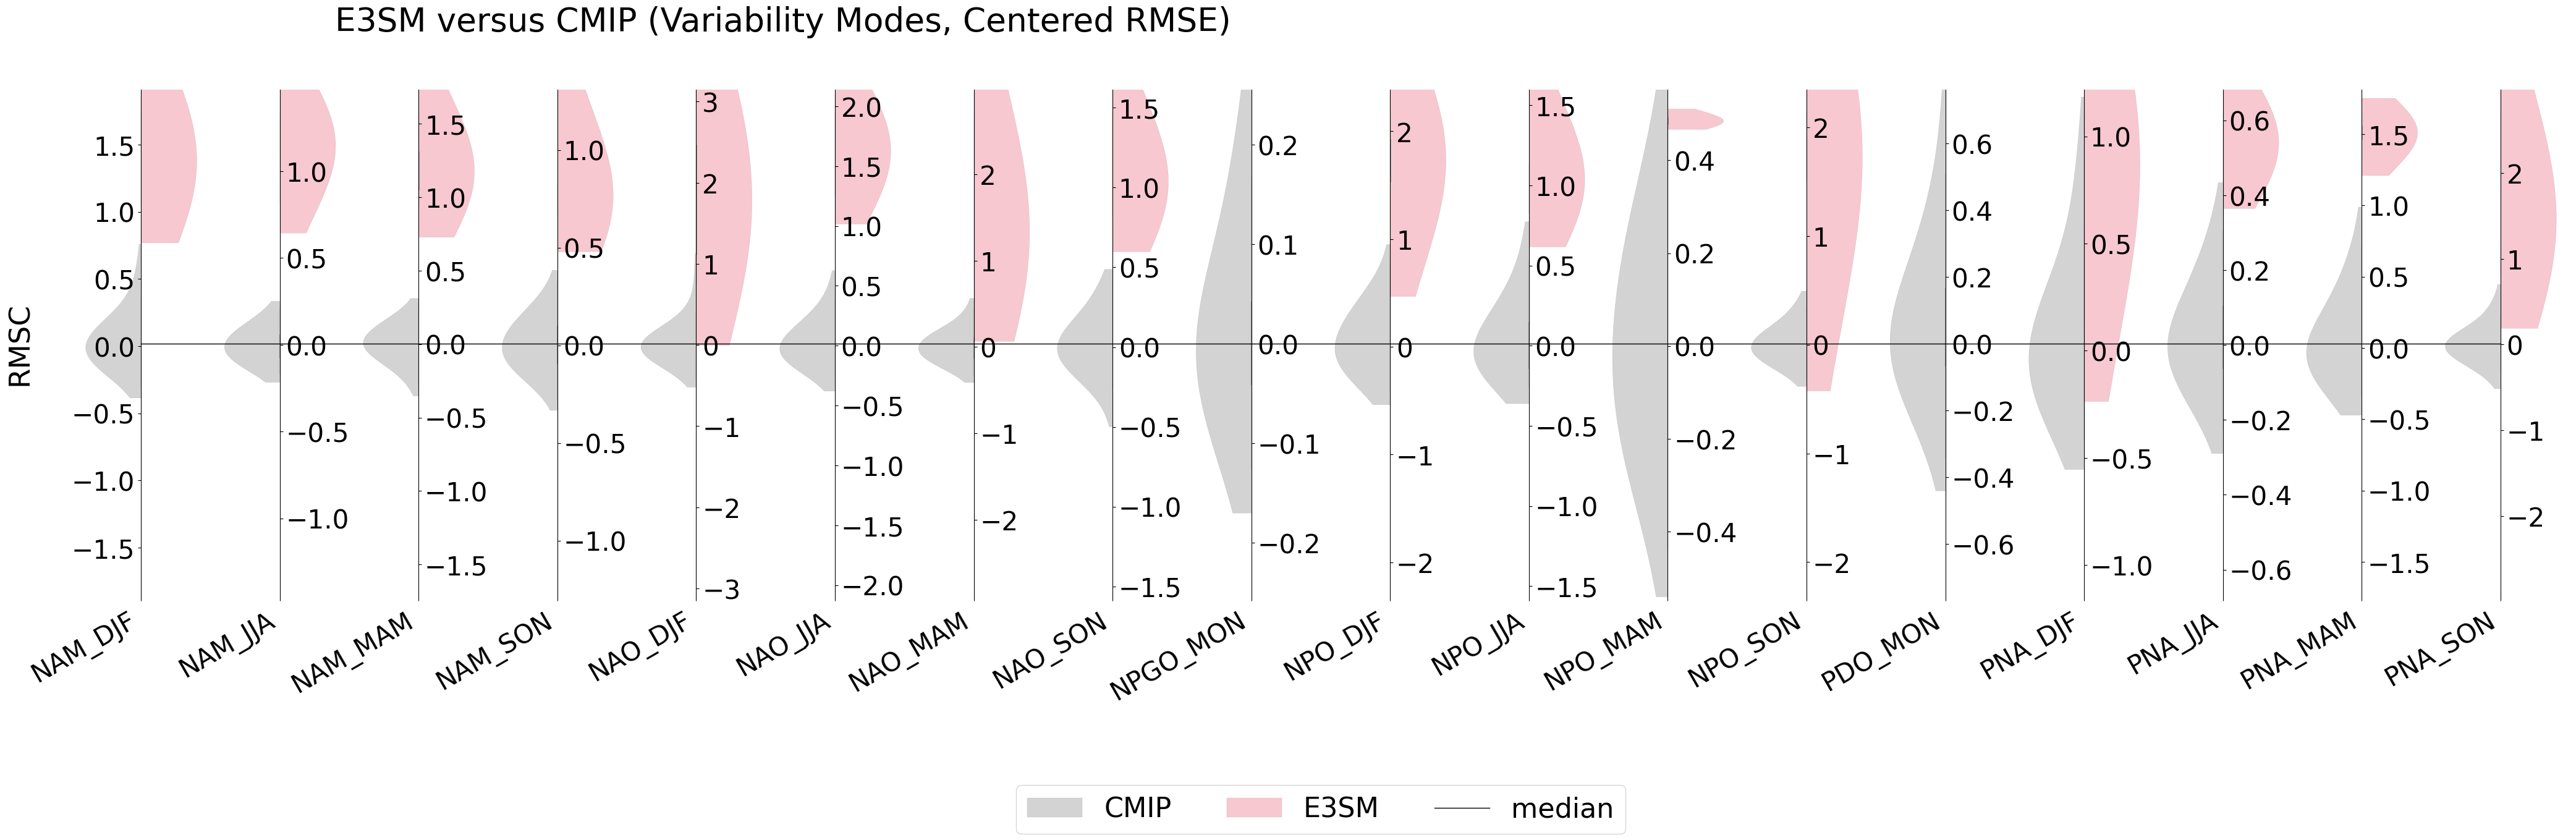

2026-08-28 16:55:08,142 [INFO]: synthetic_metrics_plotter.py(variability_modes_plot_driver:925) >> Processing Portrait  Plots for variability_modes stdv_pc_ratio_to_obs....
2026-08-28 16:55:08,149 [INFO]: synthetic_metrics_plotter.py(portrait_metric_plot:1194) >> [Portrait] Highlighted model order: ['v3.LR.CPL', 'v3.HR.CPL', 'v4P.CPL', 'v4P.AMIP']


len(mode_season_list) = 18
data_nor shape = (18, 66)
data_nor.T shape = (66, 18)
existing data_dict shape = (66, 18)
existing columns (n) = 18


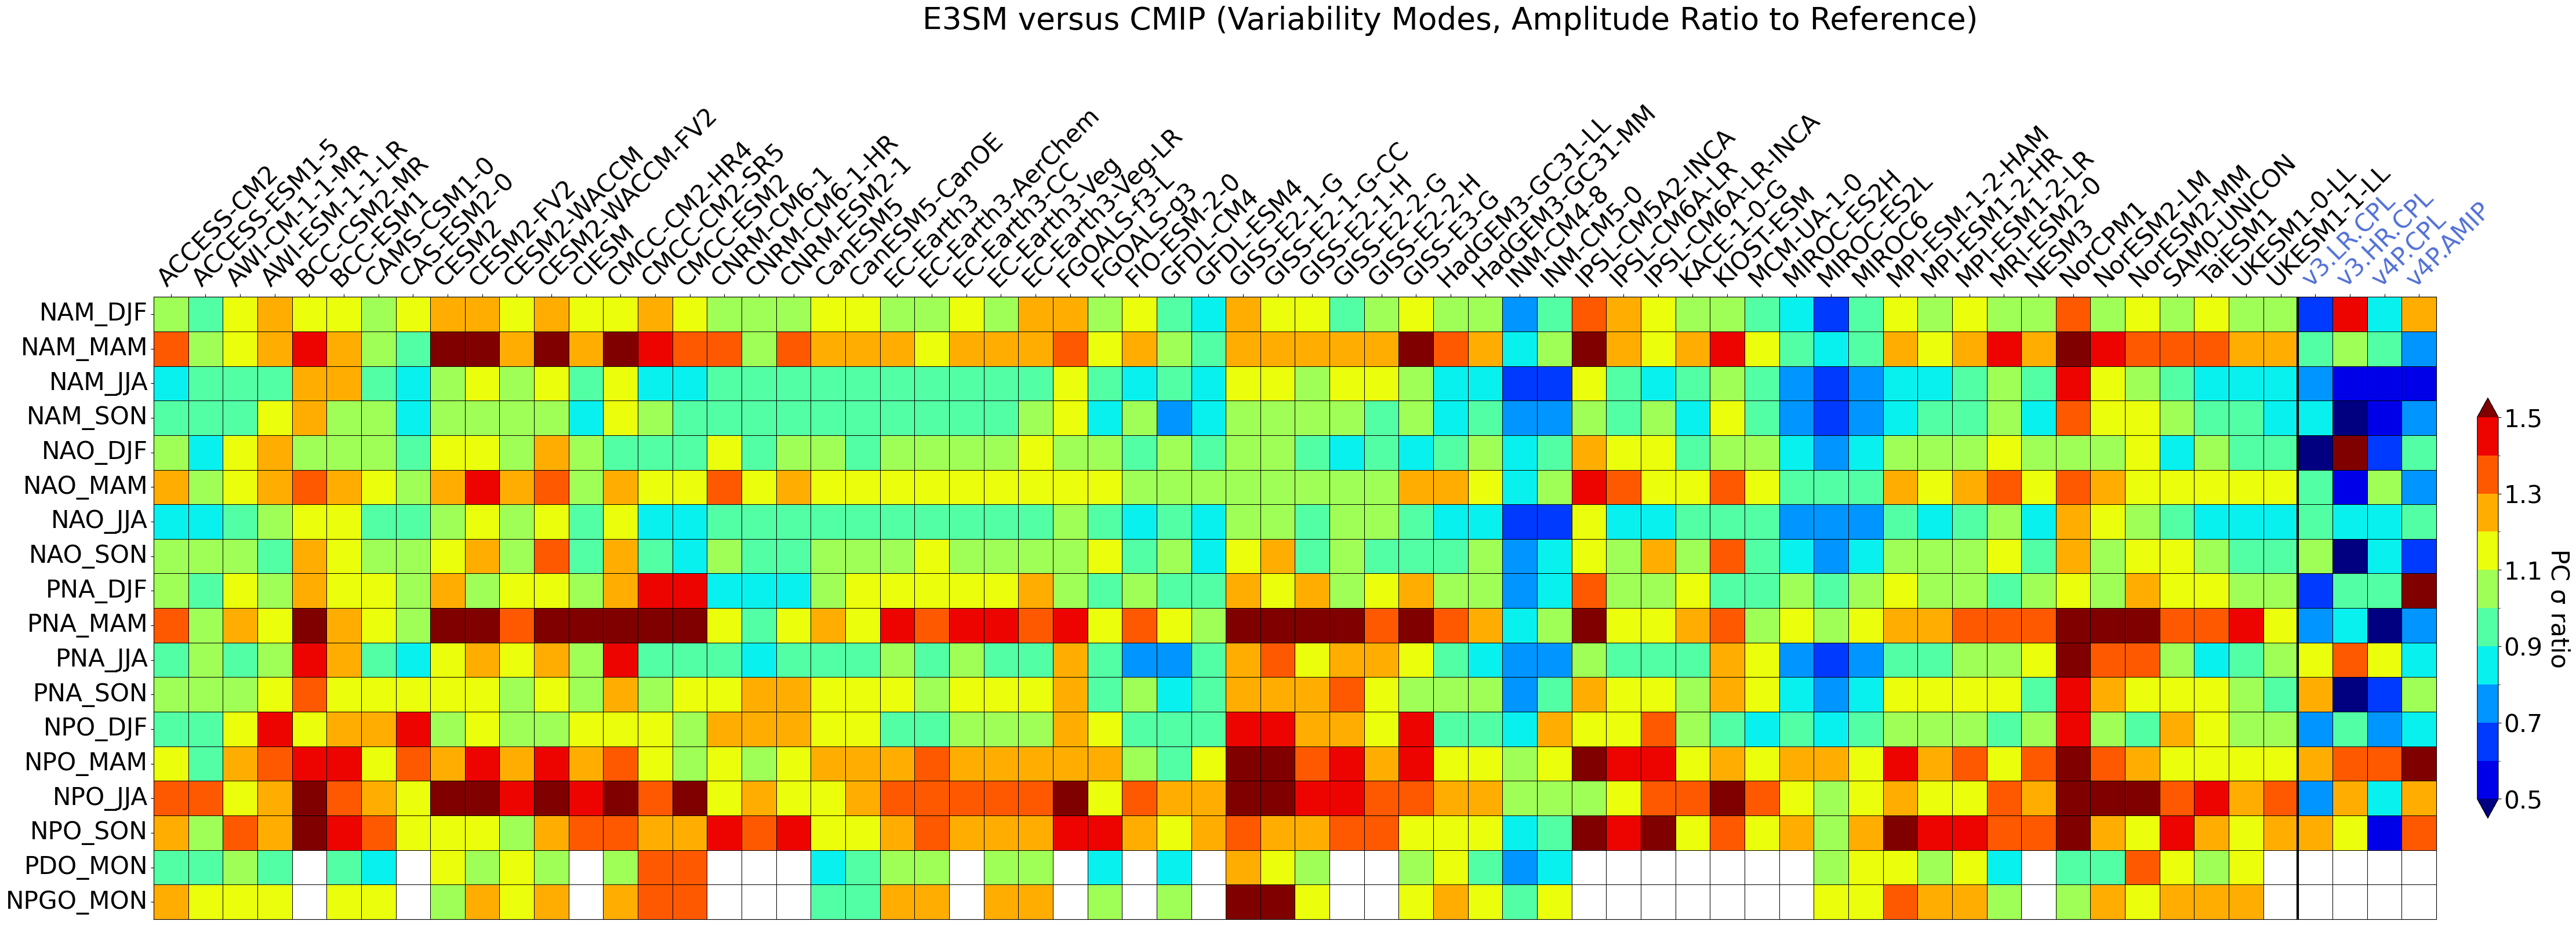

2026-08-28 16:55:10,054 [INFO]: synthetic_metrics_plotter.py(variability_modes_plot_driver:976) >> Processing Parallel Coordinate Plots for variability_modes stdv_pc_ratio_to_obs....


Models in the second group: ['v3.HR.CPL', 'v3.LR.CPL', 'v4P.AMIP', 'v4P.CPL']


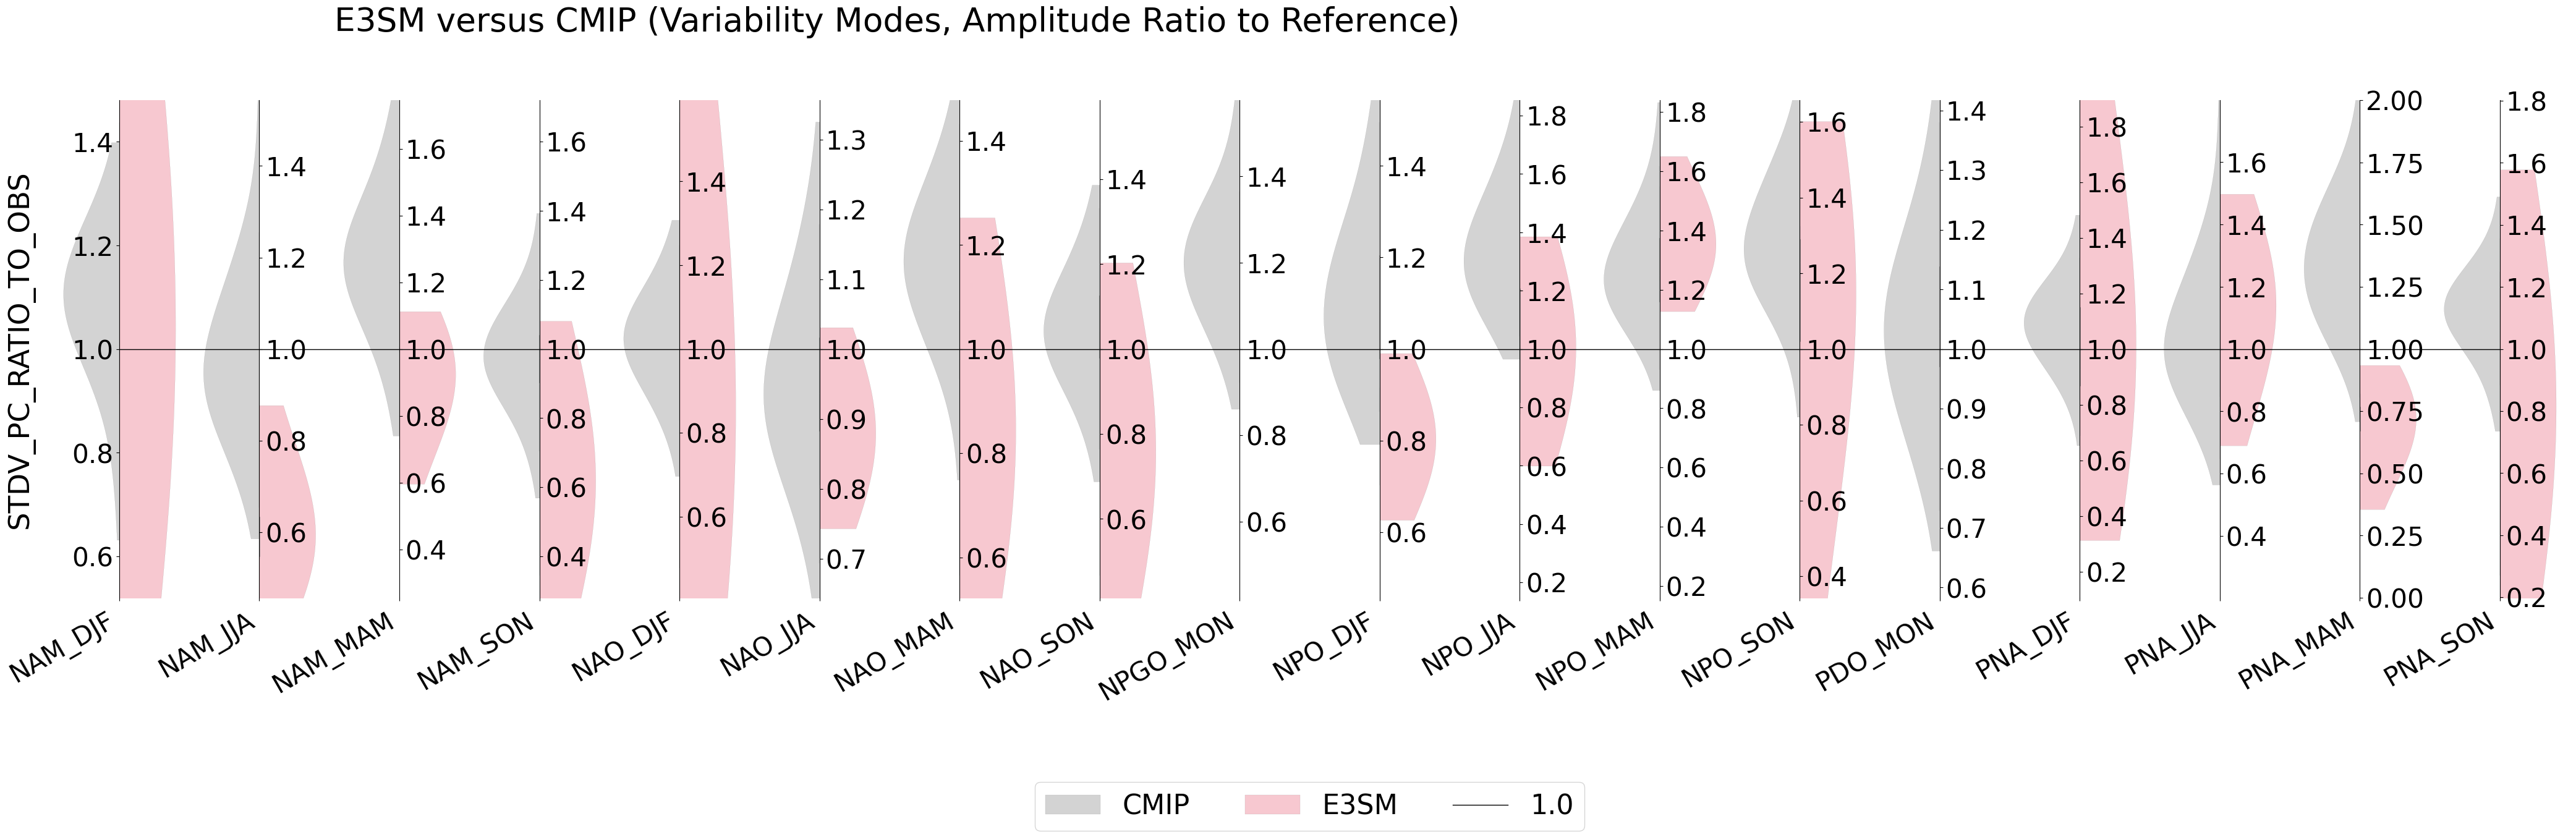

In [12]:
if MOV_MVO_V4P_RUN_MERGE:
    merge_metrics_group(
        MOV_MVO_V4P_TEST_RAW_GROUP,
        metrics_root=MOV_MVO_V4P_METRICS_DATA_ROOT,
        run_type="model_vs_obs",
        enable_clim=False,
        enable_movs=True,
        enable_enso=False,
        strict=True,
        verbose=True,
        dry_run=MOV_MVO_V4P_DRY_RUN_MERGE,
        clean=MOV_MVO_V4P_CLEAN_MERGED_OUTPUT,
    )
    MOV_MVO_V4P_TEST_COMBINED = True

# Merged test group consumed by the plot workflow.
MOV_MVO_V4P_TEST_DATASET = dataset_for_merged_group(
    mip=MOV_MVO_V4P_TEST_MIP,
    group=MOV_MVO_V4P_TEST_MERGED_GROUP,
    case_id=MOV_MVO_V4P_CASE_ID,
    root=MOV_MVO_V4P_METRICS_DATA_ROOT,
)

# Reference setup. Use built-in CMIP defaults from MOV_MVO_V4P_METRICS_DATA_ROOT.
MOV_MVO_V4P_REF_GROUP_LABEL = "CMIP"
MOV_MVO_V4P_REF_DATASET = None
MOV_MVO_V4P_ALIGN_WITH_CMIP = True

MOV_MVO_V4P_SHOW_MEAN_COLUMNS = False
MOV_MVO_V4P_MEAN_GROUP1_NAME = None #"CMIP (mean)"
MOV_MVO_V4P_MEAN_GROUP2_NAME = None #"E3SM (mean)"

# Explicit metrics and figure family.
MOV_MVO_V4P_METRICS = ("rms", "rmsc", "stdv_pc_ratio_to_obs")
MOV_MVO_V4P_SHOW_FIGURES = True
MOV_MVO_V4P_CLIM_VIEWER = False
MOV_MVO_V4P_MOVA_VIEWER = True
MOV_MVO_V4P_MOVC_VIEWER = True
MOV_MVO_V4P_ENSO_VIEWER = False

# Plot settings.
MOV_MVO_V4P_CLIM_VARS = (
    "pr,prw,psl,rlds,rldscs,rltcre,rstcre,rsus,rsuscs,rlus,rlut,rlutcs,"
    "rsds,rsdscs,rsut,rsutcs,rtmt,sfcWind,tas,tauu,tauv,ts,ta-200,ta-850,"
    "ua-200,ua-850,va-200,va-850,zg-500"
)
MOV_MVO_V4P_CLIM_REGIONS = "global"
MOV_MVO_V4P_MOVS_GROUP = "cbf"
MOV_MVO_V4P_ATM_MODES = None
MOV_MVO_V4P_ATM_OBS = "NOAA-20C"
MOV_MVO_V4P_CPL_MODES = None
MOV_MVO_V4P_CPL_OBS = "HadISST"
MOV_MVO_V4P_ERROR_NORM = "reference"
MOV_MVO_V4P_FIGURE_FORMAT = "pdf"
MOV_MVO_V4P_FONT_SIZE = 32
MOV_MVO_V4P_FIGURE_SIZE = (60.0, 20.0)  # Backward-compatible fallback.
MOV_MVO_V4P_PORTRAIT_FIGURE_SIZE = (50.0, 20.0)
MOV_MVO_V4P_PARCOORD_FIGURE_SIZE = (70.0, 30.0)

MOV_MVO_V4P_EXCLUDE_VARS = {
    "E3SM-1-0": ["ta-850"],
    "E3SM-1-1-ECA": ["ta-850"],
    "CIESM": ["pr"],
    "KIOST-ESM": ["zg-500", "ta-850"],
    "GISS-E2-2-G": ["rlutcs", "zg-500"],
}
MOV_MVO_V4P_EXCLUDE_MODELS = ["E3SM-1-0", "E3SM-1-1", "E3SM-1-1-ECA", "E3SM-2-0", "E3SM-2-1"]
MOV_MVO_V4P_EXTRA_GROUPS_NAME = [""]

mov_mvo_v4p_parameters = make_comparison_parameters(
    case_id=MOV_MVO_V4P_CASE_ID,
    ref_group=MOV_MVO_V4P_REF_GROUP_LABEL,
    test_group=MOV_MVO_V4P_TEST_GROUP_LABEL,
    ref_dataset=MOV_MVO_V4P_REF_DATASET,
    test_dataset=MOV_MVO_V4P_TEST_DATASET,
    test_highlight_models=MOV_MVO_V4P_TEST_HIGHLIGHT_MODELS,
    metrics_root=MOV_MVO_V4P_METRICS_DATA_ROOT,
    out_dir=MOV_MVO_V4P_OUTPUT_DIR,
    align_with_cmip=MOV_MVO_V4P_ALIGN_WITH_CMIP,
    test_combined=MOV_MVO_V4P_TEST_COMBINED,
    test_model_only=MOV_MVO_V4P_TEST_MODEL_ONLY,
    show_mean_columns=MOV_MVO_V4P_SHOW_MEAN_COLUMNS,
    clim_vars=MOV_MVO_V4P_CLIM_VARS,
    clim_regions=MOV_MVO_V4P_CLIM_REGIONS,
    movs_group=MOV_MVO_V4P_MOVS_GROUP,
    error_norm=MOV_MVO_V4P_ERROR_NORM,
    exclude_vars=MOV_MVO_V4P_EXCLUDE_VARS,
    exclude_models=MOV_MVO_V4P_EXCLUDE_MODELS,
    atm_modes=MOV_MVO_V4P_ATM_MODES,
    atm_obs=MOV_MVO_V4P_ATM_OBS,
    cpl_modes=MOV_MVO_V4P_CPL_MODES,
    cpl_obs=MOV_MVO_V4P_CPL_OBS,
    figure_format=MOV_MVO_V4P_FIGURE_FORMAT,
    mov_font_size=MOV_MVO_V4P_FONT_SIZE,
    mov_figure_size=MOV_MVO_V4P_FIGURE_SIZE,
    mov_portrait_figure_size=MOV_MVO_V4P_PORTRAIT_FIGURE_SIZE,
    mov_parcoord_figure_size=MOV_MVO_V4P_PARCOORD_FIGURE_SIZE,
    clim_viewer=MOV_MVO_V4P_CLIM_VIEWER,
    mova_viewer=MOV_MVO_V4P_MOVA_VIEWER,
    movc_viewer=MOV_MVO_V4P_MOVC_VIEWER,
    enso_viewer=MOV_MVO_V4P_ENSO_VIEWER,
    mean_group1_name=MOV_MVO_V4P_MEAN_GROUP1_NAME,
    mean_group2_name=MOV_MVO_V4P_MEAN_GROUP2_NAME,
    extra_groups_name=MOV_MVO_V4P_EXTRA_GROUPS_NAME,
)

if MOV_MVO_V4P_RUN_PLOTS:
    run_synthetic_plots(
        mov_mvo_v4p_parameters,
        title_label=MOV_MVO_V4P_TITLE_LABEL,
        metric_file=MOV_MVO_V4P_METRIC_CONFIG_FILE,
        metric_selection={"variability_modes": MOV_MVO_V4P_METRICS},
        show_figures=MOV_MVO_V4P_SHOW_FIGURES,
        debug=MOV_MVO_V4P_DEBUG,
    )
else:
    print("Set MOV_MVO_V4P_RUN_PLOTS = True to generate figures.")
